In [1]:
# try to mount google colab
import os
try:
  from google.colab import drive
  drive.mount('/content/drive')
  cur_dir = "/content/drive/MyDrive/ws/prj/adv_ds_2310/Lab05_Models/ex01_iris_classification/preprocessing"
except:
  cur_dir = "."
  pass
cur_dir = os.path.abspath(cur_dir)
os.chdir(cur_dir)

print(f'cur_dir: {cur_dir} \n --> {os.path.abspath(".")}')

cur_dir: c:\Users\Van Nguyen Duc Thinh\Documents\GitHub\CSTTNT25\diabete_classification\preprocessing 
 --> c:\Users\Van Nguyen Duc Thinh\Documents\GitHub\CSTTNT25\diabete_classification\preprocessing


### Khai báo thư viện (Load Libraries)

In [2]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

### Tham số chương trình

In [3]:
seed = 42

exps_dir = "../exps"
os.makedirs(exps_dir, exist_ok=True)

save_dir = f"{exps_dir}/feature1"
os.makedirs(save_dir, exist_ok=True)

### Nạp dữ liệu (Load Dataset)

In [4]:
# đường dẫn dữ liệu
data_path = os.path.join("..", "data", "pima-indians-diabetes.data.csv")

# tên từng cột của dataset
data_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# đọc dữ liệu
df_org = pd.read_csv(data_path, names=data_names)

# hiển thị dữ liệu
display.display(df_org.head())
display.display(df_org.tail())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [5]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df_org.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Chia dữ liệu thực nghiệm

+ Dữ liệu ban đầu: chia 30% dữ liệu dùng để Test, 70% dùng để train
+ Dữ liệu train: chia chiến lược K-Fold với k = 5

In [7]:
index_all = np.arange(len(df_org))
index_train, index_test = train_test_split(index_all, test_size = 0.33, random_state=seed)

In [8]:
df_train = df_org.iloc[index_train]
df_test  = df_org.iloc[index_test]
print(f'train: {len(df_train)} / test: {len(df_test)} - Tỷ lệ: {len(df_train) / len(df_org)}, {len(df_test) / len(df_org)}')

train: 514 / test: 254 - Tỷ lệ: 0.6692708333333334, 0.3307291666666667


In [9]:
# Lưu dữ liệu sau khi chia
df_train.to_excel(f'{exps_dir}/data/train.xlsx', index=None)
df_test.to_excel(f'{exps_dir}/data/test.xlsx', index=None)
np.savez(f'{exps_dir}/data/idx.npz', id_train = index_train, id_test = index_test)

In [10]:
dict(np.load(f'{exps_dir}/data/idx.npz'))

{'id_train': array([464, 223, 393, 766, 570, 671, 412, 755, 176, 525, 333, 163, 248,
        682,  74, 439, 643, 104, 114, 749,  92, 380,  89, 417, 477, 713,
        707, 506,  11,  43,  42, 167, 675, 666, 381, 178, 705, 518, 177,
        532, 539, 257, 616, 440,  15, 478, 256, 388, 360, 367, 446, 589,
        342, 453, 426,   9, 249,  22, 221, 526, 751, 752, 424, 644, 203,
        500,  93, 369, 332, 522, 284, 184, 623, 365, 153,  75, 422, 277,
         68, 695, 188, 271, 236,  88, 654, 117, 125, 633, 289, 238,   0,
        759, 368, 672, 434, 278, 602, 116, 228, 545, 698, 533, 274, 318,
        530, 144, 479, 598, 696, 711, 268, 649, 307, 310, 420,  46, 349,
        371, 595, 261, 195, 767, 645, 107,  59, 578, 664, 100, 445, 689,
        727, 423, 179, 304, 398, 444, 739, 149, 124, 611, 669, 185, 674,
        495, 436, 757, 575, 321, 353, 709, 142, 724, 141, 399, 493, 320,
         19, 172, 627, 312, 390, 715,  12, 407, 408, 305, 354,  25, 576,
        169,  38, 507, 245, 298, 641, 4

In [11]:
pd.read_excel(f'{exps_dir}/data/train.xlsx')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,10,115,98,0,0,24.0,1.022,34,0
1,7,142,60,33,190,28.8,0.687,61,0
2,4,116,72,12,87,22.1,0.463,37,0
3,1,126,60,0,0,30.1,0.349,47,1
4,3,78,70,0,0,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
509,5,139,64,35,140,28.6,0.411,26,0
510,1,96,122,0,0,22.4,0.207,27,0
511,10,101,86,37,0,45.6,1.136,38,1
512,0,141,0,0,0,42.4,0.205,29,1


In [12]:
pd.read_excel(f'{exps_dir}/data/test.xlsx')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,98,58,33,190,34.0,0.430,43,0
1,2,112,75,32,0,35.7,0.148,21,0
2,2,108,64,0,0,30.8,0.158,21,0
3,8,107,80,0,0,24.6,0.856,34,0
4,7,136,90,0,0,29.9,0.210,50,0
...,...,...,...,...,...,...,...,...,...
249,0,106,70,37,148,39.4,0.605,22,0
250,1,95,82,25,180,35.0,0.233,43,1
251,1,0,74,20,23,27.7,0.299,21,0
252,8,143,66,0,0,34.9,0.129,41,1


## Tiền xử lý dữ liệu (Data Preprocessing)

### Làm sạch dữ liệu (Data Cleaning)

#### Tạo bảng dữ liệu làm sạch
+ Chỉ giữ lại các cột Input, Ouput

In [13]:
df_train = pd.read_excel(f'{exps_dir}/data/train.xlsx')

#### Xóa dữ liệu trùng nhau

In [14]:
display.display(df_train[df_train.duplicated(keep = False)])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [15]:
df_train.drop_duplicates(ignore_index=True, inplace=True)
display.display(df_train)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,10,115,98,0,0,24.0,1.022,34,0
1,7,142,60,33,190,28.8,0.687,61,0
2,4,116,72,12,87,22.1,0.463,37,0
3,1,126,60,0,0,30.1,0.349,47,1
4,3,78,70,0,0,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
509,5,139,64,35,140,28.6,0.411,26,0
510,1,96,122,0,0,22.4,0.207,27,0
511,10,101,86,37,0,45.6,1.136,38,1
512,0,141,0,0,0,42.4,0.205,29,1


#### Kiểm tra giá trị bất thường

In [16]:
valid_ranges = {
    "Pregnancies": (0, 20),
    "Glucose": (20, 300),
    "BloodPressure": (40, 200),
    "BMI": (10, 80),
    "Age": (21, 100)
}
for col, (low, high) in valid_ranges.items():
    invalid_count = ((df_train[col] < low) | (df_train[col] > high)).sum()
    print(f"{col}: {invalid_count} giá trị ngoài khoảng [{low}, {high}]")

Pregnancies: 0 giá trị ngoài khoảng [0, 20]
Glucose: 4 giá trị ngoài khoảng [20, 300]
BloodPressure: 20 giá trị ngoài khoảng [40, 200]
BMI: 5 giá trị ngoài khoảng [10, 80]
Age: 0 giá trị ngoài khoảng [21, 100]


#### Xử lý giá trị rỗng, không hợp lệ

In [17]:
for col, (low, high) in valid_ranges.items():
    df_train = df_train[(df_train[col] >= low) & (df_train[col] <= high)]
for col, (low, high) in valid_ranges.items():
    df_test = df_test[(df_test[col] >= low) & (df_test[col] <= high)]
# Kiểm tra lại bảng dữ liệu
display.display(df_train)
display.display(df_test)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,10,115,98,0,0,24.0,1.022,34,0
1,7,142,60,33,190,28.8,0.687,61,0
2,4,116,72,12,87,22.1,0.463,37,0
3,1,126,60,0,0,30.1,0.349,47,1
4,3,78,70,0,0,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
508,2,122,76,27,200,35.9,0.483,26,0
509,5,139,64,35,140,28.6,0.411,26,0
510,1,96,122,0,0,22.4,0.207,27,0
511,10,101,86,37,0,45.6,1.136,38,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0
...,...,...,...,...,...,...,...,...,...
557,8,110,76,0,0,27.8,0.237,58,0
311,0,106,70,37,148,39.4,0.605,22,0
429,1,95,82,25,180,35.0,0.233,43,1
586,8,143,66,0,0,34.9,0.129,41,1


In [18]:
cols_zero = ["Insulin", "SkinThickness"]

for col in cols_zero:
    
    zero_count = (df_train[col] == 0).sum()
    
    print(f"Phát hiện {zero_count} giá trị 0 trong {col}")
    
    median_val = df_train.loc[df_train[col] != 0, col].median()
    
    df_train.loc[df_train[col] == 0, col] = median_val
    
    print(f" -> Đã thay thế bằng median: {median_val:.2f}")

Phát hiện 227 giá trị 0 trong Insulin
 -> Đã thay thế bằng median: 125.00
Phát hiện 127 giá trị 0 trong SkinThickness
 -> Đã thay thế bằng median: 29.00


In [19]:
cols_zero = ["Insulin", "SkinThickness"]

for col in cols_zero:
    
    zero_count = (df_test[col] == 0).sum()
    
    print(f"Phát hiện {zero_count} giá trị 0 trong {col}")
    
    median_val = df_test.loc[df_test[col] != 0, col].median()
    
    df_test.loc[df_test[col] == 0, col] = median_val
    
    print(f" -> Đã thay thế bằng median: {median_val:.2f}")

Phát hiện 105 giá trị 0 trong Insulin
 -> Đã thay thế bằng median: 129.00
Phát hiện 65 giá trị 0 trong SkinThickness
 -> Đã thay thế bằng median: 31.00


In [20]:
print("Kiểm tra lại giá trị cho Insulin và SkinThickness 0:")
print("\nBảng dữ liệu train:")
for col in cols_zero:
    print(col, (df_train[col] == 0).sum())
print("\nBảng dữ liệu test:")
for col in cols_zero:
    print(col, (df_test[col] == 0).sum())

Kiểm tra lại giá trị cho Insulin và SkinThickness 0:

Bảng dữ liệu train:
Insulin 0
SkinThickness 0

Bảng dữ liệu test:
Insulin 0
SkinThickness 0


### Biến đổi dữ liệu (Data Transforms)

#### Chuyển đổi dữ liệu danh mục (Category) thành dữ liệu số

In [21]:
# Class: LabelEncoder
class_encoder = LabelEncoder()
class_encoder.fit(df_train["Outcome"])
class_names = class_encoder.classes_
print(class_names)

# Save encoders
joblib.dump(class_encoder, f'{save_dir}/class_encoder.joblib')

# Load and check again
print(joblib.load(f'{save_dir}/class_encoder.joblib').classes_)

[0 1]
[0 1]


In [22]:
class_encoder.transform(df_train["Outcome"])

array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,

In [23]:
df_train["Outcome"] = class_encoder.transform(df_train["Outcome"])
display.display(df_train)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,10,115,98,29,125,24.0,1.022,34,0
1,7,142,60,33,190,28.8,0.687,61,0
2,4,116,72,12,87,22.1,0.463,37,0
3,1,126,60,29,125,30.1,0.349,47,1
4,3,78,70,29,125,32.5,0.270,39,0
...,...,...,...,...,...,...,...,...,...
508,2,122,76,27,200,35.9,0.483,26,0
509,5,139,64,35,140,28.6,0.411,26,0
510,1,96,122,29,125,22.4,0.207,27,0
511,10,101,86,37,125,45.6,1.136,38,1


#### Chuyển đổi dữ liệu danh mục (Category) thành dạng OneHot

Một số thuật toán khi chuyển đổi cột dạng danh mục thành kiểu OneHot thì cho hiệu suất cao hơn.

Bên cạnh đó, khi huấn luyện mô hình với dạng hàm mất mát CategoryEntropy thì cũng cần chuyển thuộc tính phân lớp sang dạng OneHot.

In [24]:
print("class_names: ", class_names)
df_onehot = pd.get_dummies(df_train["Outcome"])
df_onehot = pd.DataFrame(df_onehot.values, columns=class_names)
display.display(df_onehot)

class_names:  [0 1]


,0,1
0,True,False
1,True,False
2,True,False
3,False,True
4,True,False
...,...,...
482,True,False
483,True,False
484,True,False
485,False,True


#### Chuẩn hóa dữ liệu (Data Normalize)

Chuẩn hóa các tính chất để đưa về cùng một miền trị
+ Min-Max Normalization
$$
z = \frac{x - min(x)}{max(x) - min(x)}
$$
+ Standard Normalization
$$
z = \frac{x - \mu}{\sigma}
$$

**Lưu ý**: Quá trình chuẩn hóa có thể làm trong phần thực nghiệm thuật toán

##### Min-Max Normalization

In [25]:
# Min-Max Normalization
scale_columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(df_train[scale_columns])
df_minmax = df_train.copy()
df_minmax[scale_columns] = minmax_scaler.transform(df_train[scale_columns])
display.display(df_minmax)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.588235,0.458065,0.707317,0.381818,0.133413,0.118609,0.403074,0.216667,0
1,0.411765,0.632258,0.243902,0.454545,0.211538,0.216769,0.260034,0.666667,0
2,0.235294,0.464516,0.390244,0.072727,0.087740,0.079755,0.164389,0.266667,0
3,0.058824,0.529032,0.243902,0.381818,0.133413,0.243354,0.115713,0.433333,1
4,0.176471,0.219355,0.365854,0.381818,0.133413,0.292434,0.081981,0.300000,0
...,...,...,...,...,...,...,...,...,...
508,0.117647,0.503226,0.439024,0.345455,0.223558,0.361963,0.172929,0.083333,0
509,0.294118,0.612903,0.292683,0.490909,0.151442,0.212679,0.142186,0.083333,0
510,0.058824,0.335484,1.000000,0.381818,0.133413,0.085890,0.055081,0.100000,0
511,0.588235,0.367742,0.560976,0.527273,0.133413,0.560327,0.451751,0.283333,1


In [26]:
minmax_scaler.__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': 487,
 'scale_': array([0.05882353, 0.00645161, 0.01219512, 0.01818182, 0.00120192,
        0.0204499 , 0.42698548, 0.01666667]),
 'min_': array([ 0.        , -0.28387097, -0.48780488, -0.14545455, -0.01682692,
        -0.37218814, -0.03330487, -0.35      ]),
 'data_min_': array([ 0.   , 44.   , 40.   ,  8.   , 14.   , 18.2  ,  0.078, 21.   ]),
 'data_max_': array([ 17.  , 199.  , 122.  ,  63.  , 846.  ,  67.1 ,   2.42,  81.  ]),
 'data_range_': array([ 17.   , 155.   ,  82.   ,  55.   , 832.   ,  48.9  ,   2.342,
         60.   ])}

In [27]:
# Save encoders
joblib.dump(minmax_scaler, f'{save_dir}/minmax_scaler.joblib')

['../exps/feature1/minmax_scaler.joblib']

In [28]:
joblib.load(f'{save_dir}/minmax_scaler.joblib').__dict__

{'feature_range': (0, 1),
 'copy': True,
 'clip': False,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': 487,
 'scale_': array([0.05882353, 0.00645161, 0.01219512, 0.01818182, 0.00120192,
        0.0204499 , 0.42698548, 0.01666667]),
 'min_': array([ 0.        , -0.28387097, -0.48780488, -0.14545455, -0.01682692,
        -0.37218814, -0.03330487, -0.35      ]),
 'data_min_': array([ 0.   , 44.   , 40.   ,  8.   , 14.   , 18.2  ,  0.078, 21.   ]),
 'data_max_': array([ 17.  , 199.  , 122.  ,  63.  , 846.  ,  67.1 ,   2.42,  81.  ]),
 'data_range_': array([ 17.   , 155.   ,  82.   ,  55.   , 832.   ,  48.9  ,   2.342,
         60.   ])}

In [29]:
# save scale_columns
np.savez(f'{save_dir}/scale_columns.npz', scale_columns = scale_columns)
dict(np.load(f'{save_dir}/scale_columns.npz'))

{'scale_columns': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='<U24')}

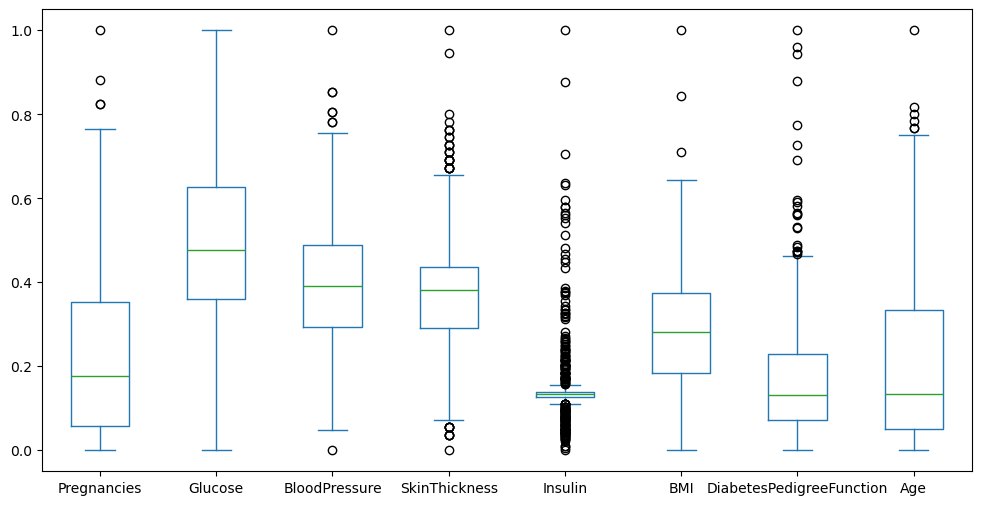

In [30]:
df_minmax[scale_columns].plot(kind="box", figsize=(12,6));

In [31]:
# Standard Normalization
standard_scaler = StandardScaler()
standard_scaler.fit(df_train[scale_columns])
df_standard = df_train.copy()
df_standard[scale_columns] = standard_scaler.transform(df_train[scale_columns])
display.display(df_standard)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.868872,-0.249202,2.117816,0.029544,-0.184595,-1.211644,1.600898,0.064777,0
1,0.960246,0.628110,-1.064927,0.489952,0.544458,-0.514127,0.622181,2.385613,0
2,0.051619,-0.216709,-0.059851,-1.927192,-0.610811,-1.487745,-0.032245,0.322647,0
3,-0.857007,0.108221,-1.064927,0.029544,-0.184595,-0.325216,-0.365301,1.182216,1
4,-0.251256,-1.451446,-0.227363,0.029544,-0.184595,0.023543,-0.596103,0.494561,0
...,...,...,...,...,...,...,...,...,...
508,-0.554131,-0.021751,0.275175,-0.200660,0.656620,0.517618,0.026186,-0.622879,0
509,0.354495,0.530631,-0.729902,0.720156,-0.016352,-0.543190,-0.184165,-0.622879,0
510,-0.857007,-0.866571,4.127970,0.029544,-0.184595,-1.444150,-0.780160,-0.536922,0
511,1.868872,-0.704105,1.112739,0.950360,-0.184595,1.927184,1.933954,0.408604,1


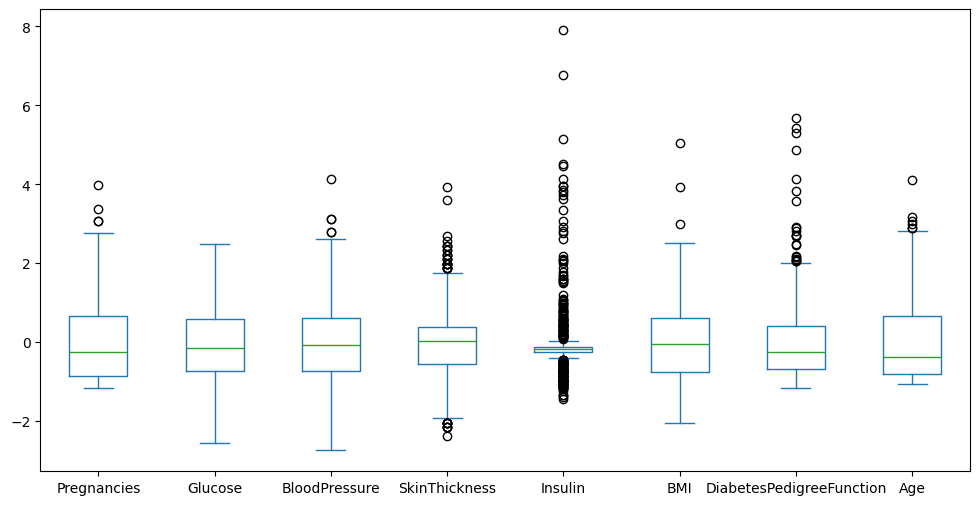

In [32]:
df_standard[scale_columns].plot(kind="box", figsize=(12,6));

In [33]:
correlations = df_standard.corr(method='pearson')
display.display(correlations)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.138558,0.163682,0.099982,0.027100,0.043737,-0.012989,0.549095,0.202095
Glucose,0.138558,1.000000,0.199100,0.126590,0.425321,0.227944,0.190337,0.273409,0.523324
BloodPressure,0.163682,0.199100,1.000000,0.197093,0.002247,0.286299,0.036661,0.326403,0.175631
SkinThickness,0.099982,0.126590,0.197093,1.000000,0.107692,0.581180,0.145638,0.110250,0.206773
Insulin,0.027100,0.425321,0.002247,0.107692,1.000000,0.129699,0.135965,0.118184,0.228079
BMI,0.043737,0.227944,0.286299,0.581180,0.129699,1.000000,0.185411,0.032349,0.319621
DiabetesPedigreeFunction,-0.012989,0.190337,0.036661,0.145638,0.135965,0.185411,1.000000,0.037519,0.160905
Age,0.549095,0.273409,0.326403,0.110250,0.118184,0.032349,0.037519,1.000000,0.291225
Outcome,0.202095,0.523324,0.175631,0.206773,0.228079,0.319621,0.160905,0.291225,1.000000


In [34]:
standard_scaler.__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': np.int64(487),
 'mean_': array([  3.82956879, 122.66940452,  72.71457906,  28.74332649,
        141.45790554,  32.33798768,   0.47403696,  33.24640657]),
 'var_': array([1.09011380e+01, 9.47149434e+02, 1.42548925e+02, 7.54803199e+01,
        7.94891763e+03, 4.73557027e+01, 1.17158869e-01, 1.35343801e+02]),
 'scale_': array([ 3.30168715, 30.77579298, 11.93938545,  8.68794106, 89.15670268,
         6.88154799,  0.34228478, 11.63373548])}

In [35]:
# Save encoders
joblib.dump(standard_scaler, f'{save_dir}/standard_scaler.joblib')

['../exps/feature1/standard_scaler.joblib']

In [36]:
joblib.load(f'{save_dir}/standard_scaler.joblib').__dict__

{'with_mean': True,
 'with_std': True,
 'copy': True,
 'feature_names_in_': array(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype=object),
 'n_features_in_': 8,
 'n_samples_seen_': np.int64(487),
 'mean_': array([  3.82956879, 122.66940452,  72.71457906,  28.74332649,
        141.45790554,  32.33798768,   0.47403696,  33.24640657]),
 'var_': array([1.09011380e+01, 9.47149434e+02, 1.42548925e+02, 7.54803199e+01,
        7.94891763e+03, 4.73557027e+01, 1.17158869e-01, 1.35343801e+02]),
 'scale_': array([ 3.30168715, 30.77579298, 11.93938545,  8.68794106, 89.15670268,
         6.88154799,  0.34228478, 11.63373548])}

### Lưu dữ liệu Features

+ Chuyển đổi dữ liệu sang dạng numpy với phần Input (X_data), Output (y_data)
+ Lưu tất cả thông tin để chuẩn bị chạy thuật toán

In [37]:
# MinMax
x_train = df_minmax.values[:, :-1]
y_train = df_minmax.values[:, -1]
display.display(df_minmax.head())

print("+ x_train: \n ", x_train[:5, :])
print("+ y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_minmax.npz', x_train = x_train, y_train = y_train)
df_minmax.to_excel(f'{save_dir}/df_minmax.xlsx', index=False)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.588235,0.458065,0.707317,0.381818,0.133413,0.118609,0.403074,0.216667,0
1,0.411765,0.632258,0.243902,0.454545,0.211538,0.216769,0.260034,0.666667,0
2,0.235294,0.464516,0.390244,0.072727,0.087740,0.079755,0.164389,0.266667,0
3,0.058824,0.529032,0.243902,0.381818,0.133413,0.243354,0.115713,0.433333,1
4,0.176471,0.219355,0.365854,0.381818,0.133413,0.292434,0.081981,0.300000,0


+ x_train: 
  [[0.58823529 0.45806452 0.70731707 0.38181818 0.13341346 0.11860941
  0.4030743  0.21666667]
 [0.41176471 0.63225806 0.24390244 0.45454545 0.21153846 0.21676892
  0.26003416 0.66666667]
 [0.23529412 0.46451613 0.3902439  0.07272727 0.08774038 0.0797546
  0.16438941 0.26666667]
 [0.05882353 0.52903226 0.24390244 0.38181818 0.13341346 0.24335378
  0.11571307 0.43333333]
 [0.17647059 0.21935484 0.36585366 0.38181818 0.13341346 0.29243354
  0.08198121 0.3       ]]
+ y_train: 
  [0. 0. 0. 1. 0.]


In [38]:
# MinMax
x_train = df_standard.values[:, :-1]
y_train = df_standard.values[:, -1]
display.display(df_standard.head())

print("+ x_train: \n ", x_train[:5, :])
print("+ y_train: \n ", y_train[:5])

np.savez(f'{save_dir}/feat_standard.npz', x_train = x_train, y_train = y_train)
df_standard.to_excel(f'{save_dir}/df_standard.xlsx', index=False)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.868872,-0.249202,2.117816,0.029544,-0.184595,-1.211644,1.600898,0.064777,0
1,0.960246,0.628110,-1.064927,0.489952,0.544458,-0.514127,0.622181,2.385613,0
2,0.051619,-0.216709,-0.059851,-1.927192,-0.610811,-1.487745,-0.032245,0.322647,0
3,-0.857007,0.108221,-1.064927,0.029544,-0.184595,-0.325216,-0.365301,1.182216,1
4,-0.251256,-1.451446,-0.227363,0.029544,-0.184595,0.023543,-0.596103,0.494561,0


+ x_train: 
  [[ 1.86887217 -0.2492025   2.11781595  0.02954365 -0.18459527 -1.2116442
   1.60089807  0.06477657]
 [ 0.9602458   0.62811039 -1.06492743  0.48995193  0.54445816 -0.51412672
   0.62218086  2.38561324]
 [ 0.05161943 -0.21670943 -0.05985057 -1.92719154 -0.61081112 -1.48774486
  -0.03224497  0.32264731]
 [-0.85700694  0.10822127 -1.06492743  0.02954365 -0.18459527 -0.32521573
  -0.36530097  1.18221645]
 [-0.25125603 -1.45144609 -0.22736338  0.02954365 -0.18459527  0.02354301
  -0.59610294  0.49456114]]
+ y_train: 
  [0. 0. 0. 1. 0.]


#### Hount-out (tiếp tục chia 7/3 với train/valid)

In [39]:
# Tách feature và label

X_train = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]

X_test  = df_test.iloc[:, :-1]
y_test  = df_test.iloc[:, -1]

In [40]:
scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)
x_test  = scaler.transform(X_test)
y_train = y_train.values

In [41]:
X_train_hold, X_valid_hold, y_train_hold, y_valid_hold = train_test_split(
    x_train,
    y_train,
    test_size=0.3,
    random_state=seed,
    stratify=y_train
)

print("Hold-out split")
print("Train:", X_train_hold.shape)
print("Valid:", X_valid_hold.shape)

Hold-out split
Train: (340, 8)
Valid: (147, 8)


#### k-fold (chia thành k phần đều nhau với k-1 phần cho train/1 phần cho valid)

In [42]:
kfold = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=seed
)

print(kfold)

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)


In [43]:
for train_idx, valid_idx in kfold.split(x_train, y_train):

    X_train_k = x_train[train_idx]
    y_train_k = y_train[train_idx]

    X_valid_k = x_train[valid_idx]
    y_valid_k = y_train[valid_idx]

    print("Train:", X_train_k.shape, "Valid:", X_valid_k.shape)
    break

Train: (438, 8) Valid: (49, 8)


#### Xử lý train/test và lưu dữ liệu

In [44]:
idx = np.arange(len(x_train))
train_idx_hold, valid_idx_hold = train_test_split(
    idx,
    test_size=0.3,
    random_state=seed
)
X_train_hold = x_train[train_idx_hold]
y_train_hold = y_train[train_idx_hold]

X_valid_hold = x_train[valid_idx_hold]
y_valid_hold = y_train[valid_idx_hold]
np.savez(
    f'{save_dir}/holdout_idx.npz',
    train_index=train_idx_hold,
    valid_index=valid_idx_hold
)

## Lượng giá thuật toán (Evaluate Algorithm)

#### Khởi tạo danh sách mô hình

In [45]:
models = []

models.append(("LR", LogisticRegression()))
models.append(("LDA", LinearDiscriminantAnalysis()))
models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC()))

#### Huấn luyện bằng k-fold

##### Đưa ra kết quả là baseline comparison

In [46]:
results = []
names = []

for name, model in models:

    scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=kfold,
        scoring="accuracy"
    )

    results.append(scores)
    names.append(name)

    print(name)
    print("Accuracy:", scores.mean())
    print("Std:", scores.std())
    print("----------------")

LR
Accuracy: 0.7720663265306122
Std: 0.04726179843101965
----------------
LDA
Accuracy: 0.7721513605442176
Std: 0.041005641774539366
----------------
KNN
Accuracy: 0.7477891156462585
Std: 0.0716473508091368
----------------
CART
Accuracy: 0.704124149659864
Std: 0.09520742680711798
----------------
NB
Accuracy: 0.753656462585034
Std: 0.056858513172203494
----------------
SVM
Accuracy: 0.7740646258503401
Std: 0.045914902867541164
----------------


#### Tuning KNN

In [47]:
param_grid = {
    "n_neighbors": [3,5,7,9,11]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=kfold,
    scoring="accuracy"
)

grid.fit(x_train, y_train)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: 0.7763605442176871
Best params: {'n_neighbors': 7}


#### Tuning SVM

In [48]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=kfold,
    scoring="accuracy"
)

grid.fit(x_train, y_train)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: 0.7762755102040816
Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [49]:
best_knn = grid.best_estimator_

best_knn.fit(x_train, y_train)

,C,0.1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [50]:
y_pred = best_knn.predict(x_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7424892703862661


In [51]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[130  27]
 [ 33  43]]


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       157
           1       0.61      0.57      0.59        76

    accuracy                           0.74       233
   macro avg       0.71      0.70      0.70       233
weighted avg       0.74      0.74      0.74       233



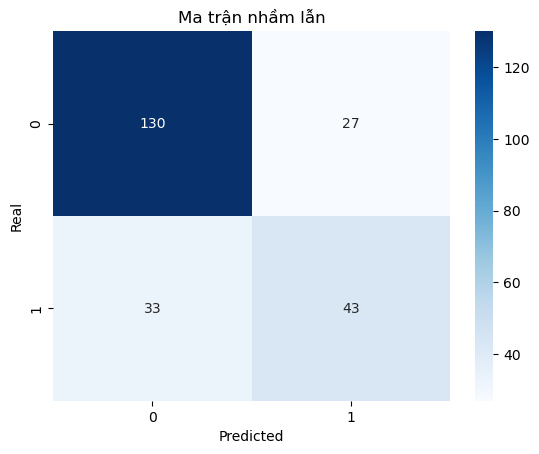

In [53]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Ma trận nhầm lẫn")
plt.show()

In [54]:
!del diabete_preprocessing.html
!jupyter nbconvert diabete_preprocessing.ipynb --to html

[NbConvertApp] Converting notebook diabete_preprocessing.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 553948 bytes to diabete_preprocessing.html
